In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("/content/all_tickets_processed_improved_v3.csv")

In [4]:
df.head()


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [5]:
df.columns

Index(['Document', 'Topic_group'], dtype='object')

In [6]:
df.isnull().sum()

,0
Document,0
Topic_group,0


In [26]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report,precision_score,confusion_matrix

In [8]:
print(df["Topic_group"].value_counts())

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [19]:
X=df["Document"]
y=df["Topic_group"]

In [36]:
vectorizer=TfidfVectorizer()
X_tfidf=vectorizer.fit_transform(X)

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X_tfidf,y,test_size=0.2,random_state=42)

In [33]:
from sklearn.linear_model import LogisticRegression
model2=LogisticRegression()
model2.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [23]:
y_pred2=model2.predict(X_test)

In [24]:
print("Accuracy:",accuracy_score(y_test,y_pred2))
print("Classification Report:\n",classification_report(y_test,y_pred2))
print("Precision Score:",precision_score(y_test,y_pred2,average="weighted"))

Accuracy: 0.8519021739130435
Classification Report:
                        precision    recall  f1-score   support

               Access       0.92      0.86      0.89      1455
Administrative rights       0.87      0.67      0.75       342
           HR Support       0.85      0.84      0.85      2107
             Hardware       0.79      0.90      0.84      2760
     Internal Project       0.92      0.79      0.85       451
        Miscellaneous       0.82      0.83      0.83      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.94      0.83      0.88       556

             accuracy                           0.85      9568
            macro avg       0.89      0.82      0.85      9568
         weighted avg       0.86      0.85      0.85      9568

Precision Score: 0.8567389698258945


<function matplotlib.pyplot.show(close=None, block=None)>

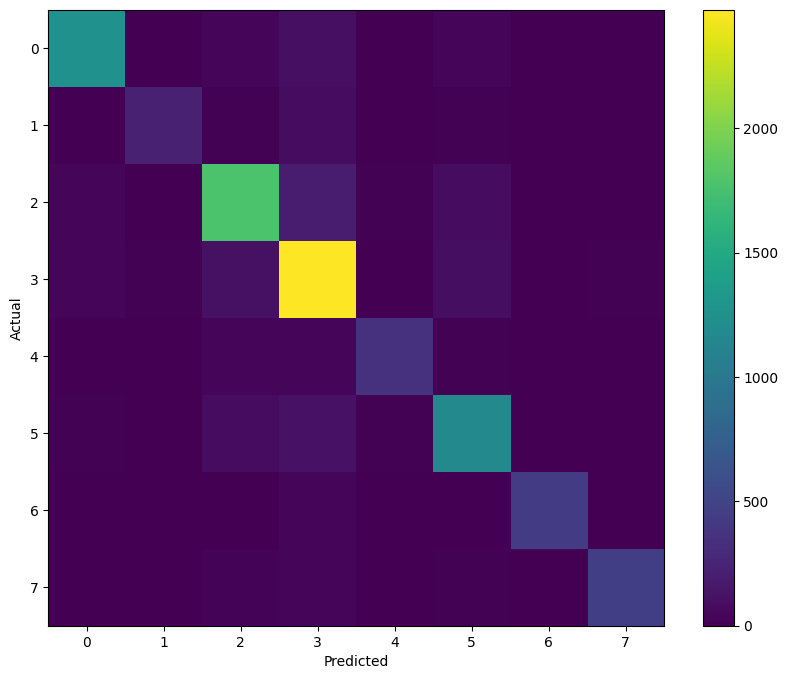

In [27]:
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred2)
plt.figure(figsize=(10,8))
plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show


In [37]:
sample=["Name admin rights to install software on my laptop"]
# Ensure 'vectorizer' has been previously fitted on the entire training data 'X' (e.g., by running cell Y1wxw2jlzgv3)
# If 'vectorizer' was accidentally re-fitted on a smaller dataset, it will cause a feature mismatch error.
sample_tifdf=vectorizer.transform(sample)
prediction=model2.predict(sample_tifdf)
print("Predicted Category",prediction[0])

Predicted Category Administrative rights


In [38]:
import joblib
joblib.dump(model2,"ticket_classifier.pkl")
joblib.dump(vectorizer,"tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [39]:
def get_priority(text):

    text = text.lower()

    high_keywords = [
        "server down",
        "system outage",
        "critical",
        "unable to work",
        "production"
    ]

    medium_keywords = [
        "access",
        "permission",
        "password",
        "software install"
    ]
    for word in high_keywords:
        if word in text:
            return "High"
    for word in medium_keywords:
        if word in text:
            return "Medium"
    return "Low"

In [44]:
sample=["Name admin rights to install software on my laptop"]

sample_tifdf=vectorizer.transform(sample)
prediction=model2.predict(sample_tifdf)
print("Predicted Category",prediction[0])

print("Predicted Priority:", get_priority(sample[0]))

Predicted Category Administrative rights
Predicted Priority: Low


In [45]:
from google.colab import files
files.download("ticket_classifier.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>